# ⚾ Baseball Salary Analysis 2025
## Comprehensive analysis of player salaries vs performance

This notebook analyzes the relationship between player salaries and performance metrics for the 2025 season, with separate analysis for pitchers and batters.

### 📊 Analysis Includes:
- **Salary Leaderboards** - Top paid players by position
- **Performance Correlations** - WAR, wOBA, ERA vs salary relationships  
- **Market Efficiency** - Best value players and team efficiency
- **Expected vs Actual** - Performance vs predictions analysis
- **Service Time Analysis** - Experience vs compensation trends
- **Advanced Metrics** - Modern sabermetrics correlations


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette('husl')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("📊 Libraries loaded successfully!")


📊 Libraries loaded successfully!


In [2]:
# Load the processed baseball salary data
print("📊 Loading baseball salary data...")
try:
    df = pd.read_csv('baseball_salary_data_2025.csv')
    print(f"✅ Data loaded successfully: {df.shape[0]} players, {df.shape[1]} columns")
except FileNotFoundError:
    print("❌ File 'baseball_salary_data_2025.csv' not found.")
    print("Please make sure you've run the data preparation notebook first.")
    raise

# Basic info
print(f"\n📋 Dataset Overview:")
print(f"Total players: {len(df)}")
print(f"Players with salary data: {df['salary_2025'].notna().sum()}")
if df['salary_2025'].notna().sum() > 0:
    print(f"Salary range: ${df['salary_2025'].min():,.0f} - ${df['salary_2025'].max():,.0f}")
    print(f"Average salary: ${df['salary_2025'].mean():,.0f}")
    print(f"Median salary: ${df['salary_2025'].median():,.0f}")

# Show column names
print(f"\n📋 Available columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

# Show sample data
print(f"\n🔍 Sample data:")
df.head()


📊 Loading baseball salary data...
✅ Data loaded successfully: 1059 players, 64 columns

📋 Dataset Overview:
Total players: 1059
Players with salary data: 863
Salary range: $760,000 - $61,875,000
Average salary: $4,929,528
Median salary: $1,400,000

📋 Available columns (64):
 1. Season
 2. player_id
 3. player_name
 4. position
 5. is_pitcher
 6. handedness
 7. mls_years
 8. salary_2025
 9. TeamName
10. TeamNameAbb
11. PA
12. AB
13. G
14. GS
15. IP
16. TBF
17. WAR
18. wRC+
19. OPS
20. AVG
21. OBP
22. SLG
23. HR
24. RBI
25. SB
26. wOBA
27. xwOBA
28. ERA
29. FIP
30. WHIP
31. K/9
32. BB/9
33. W
34. SV
35. xFIP
36. SIERA
37. wRAA
38. wRC
39. FIP-
40. xFIP-
41. K-BB%
42. WHIP+
43. woba
44. xwoba
45. launch_speed
46. launch_angle
47. hardhit_percent
48. barrels_per_bbe_percent
49. velocity
50. spin_rate
51. effective_speed
52. release_extension
53. pa
54. abs
55. pitches
56. hits
57. singles
58. doubles
59. triples
60. hrs
61. batter_run_value_per_100
62. pitcher_run_value_per_100
63. run_exp

,Season,player_id,player_name,position,is_pitcher,handedness,mls_years,salary_2025,TeamName,TeamNameAbb,PA,AB,G,GS,IP,TBF,WAR,wRC+,OPS,AVG,OBP,SLG,HR,RBI,SB,wOBA,xwOBA,ERA,FIP,WHIP,K/9,BB/9,W,SV,xFIP,SIERA,wRAA,wRC,FIP-,xFIP-,K-BB%,WHIP+,woba,xwoba,launch_speed,launch_angle,hardhit_percent,barrels_per_bbe_percent,velocity,spin_rate,effective_speed,release_extension,pa,abs,pitches,hits,singles,doubles,triples,hrs,batter_run_value_per_100,pitcher_run_value_per_100,run_exp,pitcher_run_exp
0,2025.0,665742.0,Juan Soto,OF,False,L,6.134,61875000.0,NYM,NYM,688.0,554.0,154.0,NaN,NaN,NaN,5.910344,158.706602,0.933713,0.267148,0.399417,0.534296,42.0,104.0,35.0,0.394632,0.442026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.243577,126.742832,NaN,NaN,NaN,NaN,0.395,0.443,93.7,11.3,56.103286,18.309859,89.5,2275.0,89.57,6.45,675.0,554.0,2869.0,148.0,85.0,20.0,1.0,42.0,2.103590,-2.103590,60.352,-60.352
1,2025.0,554430.0,Zack Wheeler,P,True,R,11.098,42000000.0,PHI,PHI,NaN,NaN,24.0,24.0,149.2,585.0,4.007287,NaN,NaN,0.196691,NaN,NaN,19.0,NaN,NaN,NaN,NaN,2.706014,3.012137,0.935412,11.726059,1.984410,10.0,0.0,2.735234,2.730806,NaN,NaN,71.911077,66.737709,0.276923,72.070599,0.264,0.253,87.3,13.0,34.097421,7.163324,91.5,2431.0,92.85,7.18,585.0,542.0,2394.0,107.0,65.0,21.0,2.0,19.0,-1.024394,1.024394,-24.524,24.524
2,2025.0,594798.0,Jacob deGrom,P,True,R,10.139,40000000.0,TEX,TEX,NaN,NaN,29.0,29.0,167.2,652.0,3.298453,NaN,NaN,0.195759,NaN,NaN,25.0,NaN,NaN,NaN,NaN,3.005964,3.670618,0.930418,9.500995,1.932406,12.0,0.0,3.406542,3.375131,NaN,NaN,86.366408,80.604986,0.216258,72.312046,0.260,0.292,89.8,16.1,41.570439,9.006928,93.1,2505.0,93.66,6.72,652.0,608.0,2540.0,120.0,75.0,19.0,1.0,25.0,-1.234764,1.234764,-31.363,31.363
3,2025.0,592450.0,Aaron Judge,OF,False,R,8.051,40000000.0,NYY,NYY,652.0,521.0,146.0,NaN,NaN,NaN,9.200007,199.008416,1.122705,0.326296,0.450920,0.671785,49.0,105.0,12.0,0.455963,0.470293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.370046,152.604805,NaN,NaN,NaN,NaN,0.455,0.466,95.4,19.3,57.723577,24.661247,89.3,2282.0,89.36,6.44,619.0,521.0,2540.0,170.0,90.0,29.0,2.0,49.0,2.757520,-2.757520,70.041,-70.041
4,2025.0,621043.0,Carlos Correa,SS,False,R,9.119,37333333.0,- - -,2 Tms,566.0,523.0,139.0,NaN,NaN,NaN,2.360532,103.519420,0.726473,0.273423,0.326855,0.399618,13.0,50.0,0.0,0.318691,0.343811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.293020,69.340372,NaN,NaN,NaN,NaN,0.319,0.342,90.5,7.4,45.853659,7.073171,90.2,2293.0,90.41,6.48,566.0,523.0,2217.0,143.0,103.0,27.0,0.0,13.0,-0.226613,0.226613,-5.024,5.024


In [3]:
# Create is_pitcher flag based on available data
print("🔍 Creating pitcher/batter classification...")

# Method 1: Use position if available
if 'position' in df.columns:
    df['is_pitcher'] = (df['position'] == 'P') | (df['position'].str.contains('P', na=False))
    print("✅ Using position for classification")
# Method 2: Use pitching vs batting stats
elif 'ERA' in df.columns and 'OPS' in df.columns:
    df['is_pitcher'] = df['ERA'].notna() & df['OPS'].isna()
    print("✅ Using ERA/OPS presence for classification")
# Method 3: Use Throws vs Bats
elif 'Throws' in df.columns and 'Bats' in df.columns:
    df['is_pitcher'] = df['Throws'].notna() & df['Bats'].isna()
    print("✅ Using Throws/Bats presence for classification")
else:
    print("⚠️ Cannot determine pitcher vs batter - creating basic classification")
    df['is_pitcher'] = False

# Show breakdown
pitcher_count = df['is_pitcher'].sum()
batter_count = (~df['is_pitcher']).sum()
print(f"\n📊 Player Classification:")
print(f"⚾ Pitchers: {pitcher_count}")
print(f"🏏 Batters: {batter_count}")
print(f"📊 Total: {pitcher_count + batter_count}")

# Show sample by position type
if pitcher_count > 0:
    print(f"\n🔍 Sample pitchers:")
    print(df[df['is_pitcher']]['player_name'].head(3).tolist())

if batter_count > 0:
    print(f"\n🔍 Sample batters:")
    print(df[~df['is_pitcher']]['player_name'].head(3).tolist())


🔍 Creating pitcher/batter classification...
✅ Using position for classification

📊 Player Classification:
⚾ Pitchers: 569
🏏 Batters: 490
📊 Total: 1059

🔍 Sample pitchers:
['Zack Wheeler', 'Jacob deGrom', 'Tyler Glasnow']

🔍 Sample batters:
['Juan Soto', 'Aaron Judge', 'Carlos Correa']


## 💰 Salary Leaderboards

Let's examine the highest paid players overall and by position type.


In [4]:
# Overall highest paid players
print("🏆 TOP 15 HIGHEST PAID PLAYERS (2025)")
print("=" * 50)

# Select display columns dynamically
display_cols = ['player_name', 'salary_2025', 'is_pitcher']
if 'position' in df.columns:
    display_cols.insert(-1, 'position')
if 'TeamName' in df.columns:
    display_cols.insert(-2, 'TeamName')
elif 'TeamNameAbb' in df.columns:
    display_cols.insert(-2, 'TeamNameAbb')
if 'mls_years' in df.columns:
    display_cols.insert(-1, 'mls_years')

# Get top paid players
top_paid = df.dropna(subset=['salary_2025']).nlargest(15, 'salary_2025')[display_cols].copy()

# Format for display
for i, (idx, row) in enumerate(top_paid.iterrows()):
    player_type = "Pitcher" if row['is_pitcher'] else "Batter"
    team = row.get('TeamName', row.get('TeamNameAbb', 'Unknown'))
    position = row.get('position', 'Unknown')
    service_time = f" ({row['mls_years']:.1f} yrs)" if 'mls_years' in df.columns and pd.notna(row.get('mls_years')) else ""
    
    print(f"{i+1:2d}. {row['player_name']:<20} ${row['salary_2025']:>10,.0f}  {player_type:<8} {team:<5} {position:<3}{service_time}")

# Basic salary stats by position
salary_data = df.dropna(subset=['salary_2025'])
pitcher_salaries = salary_data[salary_data['is_pitcher']]['salary_2025']
batter_salaries = salary_data[~salary_data['is_pitcher']]['salary_2025']

print(f"\n💰 SALARY STATISTICS:")
if len(pitcher_salaries) > 0:
    print(f"Average pitcher salary: ${pitcher_salaries.mean():,.0f}")
    print(f"Highest pitcher salary: ${pitcher_salaries.max():,.0f}")
if len(batter_salaries) > 0:
    print(f"Average batter salary: ${batter_salaries.mean():,.0f}")
    print(f"Highest batter salary: ${batter_salaries.max():,.0f}")


🏆 TOP 15 HIGHEST PAID PLAYERS (2025)
 1. Juan Soto            $61,875,000  Batter   NYM   OF  (6.1 yrs)
 2. Zack Wheeler         $42,000,000  Pitcher  PHI   P   (11.1 yrs)
 3. Jacob deGrom         $40,000,000  Pitcher  TEX   P   (10.1 yrs)
 4. Aaron Judge          $40,000,000  Batter   NYY   OF  (8.1 yrs)
 5. Carlos Correa        $37,333,333  Batter   - - - SS  (9.1 yrs)
 6. Mike Trout           $37,116,667  Batter   LAA   OF  (13.1 yrs)
 7. Jose Altuve          $33,000,000  Batter   HOU   2B  (13.1 yrs)
 8. Corey Seager         $32,500,000  Batter   TEX   SS  (9.0 yrs)
 9. Tyler Glasnow        $32,500,000  Pitcher  LAD   P   (7.2 yrs)
10. Giancarlo Stanton    $32,000,000  Batter   NYY   DH/OF (14.1 yrs)
11. Pete Alonso          $30,000,000  Batter   NYM   1B  (6.0 yrs)
12. Vladimir Guerrero Jr. $28,500,000  Batter   TOR   1B  (5.2 yrs)
13. Dansby Swanson       $28,000,000  Batter   CHC   SS  (8.0 yrs)
14. Carlos Rodón         $27,833,333  Pitcher  NYY   P   (9.2 yrs)
15. Cody Bellinge

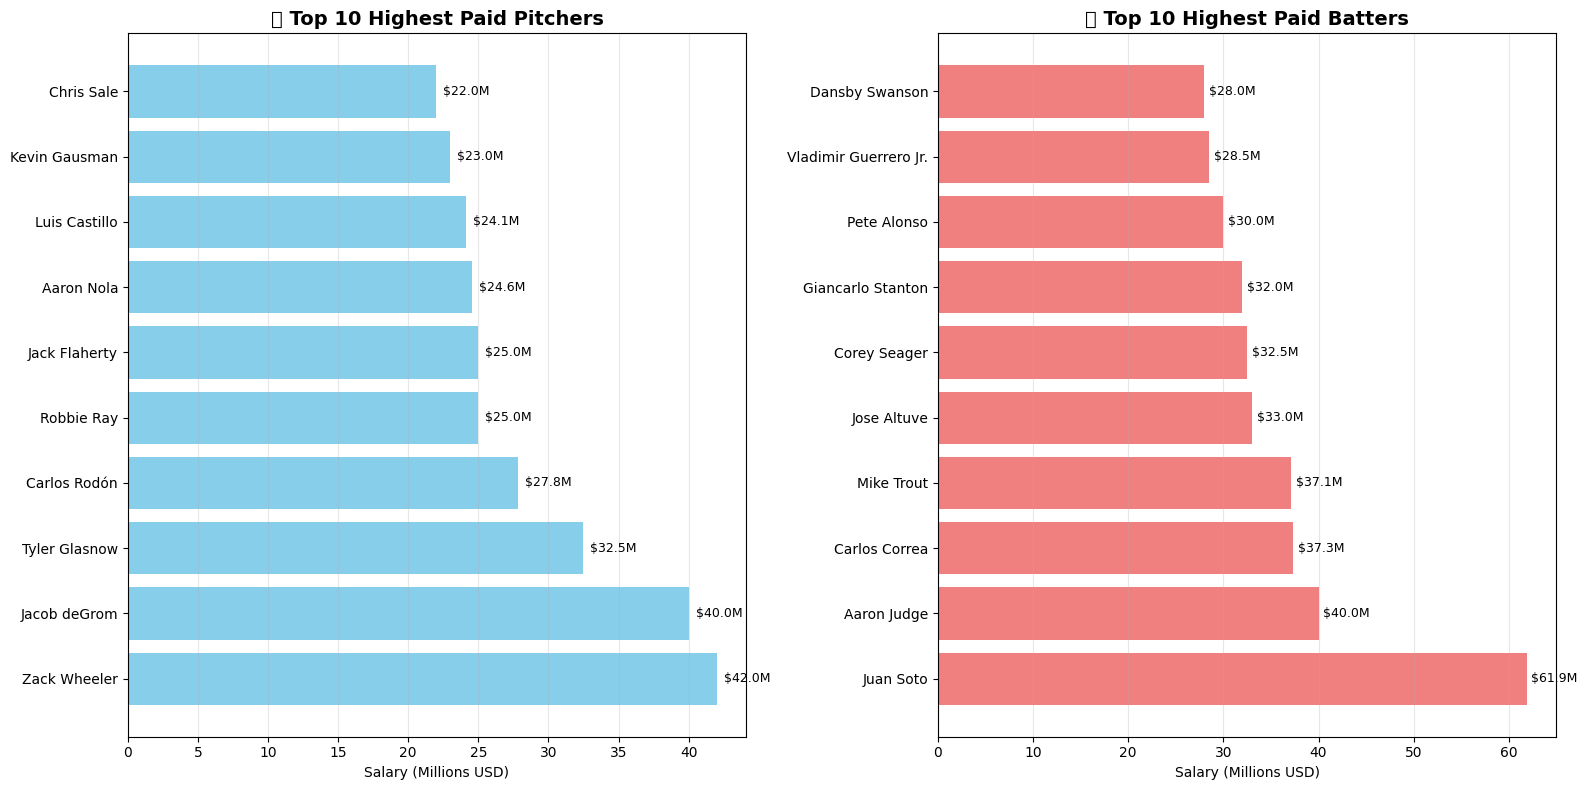

In [5]:
# Visualize top paid players by position
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Top paid pitchers
top_pitchers = df[df['is_pitcher'] & df['salary_2025'].notna()].nlargest(10, 'salary_2025')
if len(top_pitchers) > 0:
    bars1 = ax1.barh(range(len(top_pitchers)), top_pitchers['salary_2025'] / 1_000_000, color='skyblue')
    ax1.set_yticks(range(len(top_pitchers)))
    ax1.set_yticklabels(top_pitchers['player_name'], fontsize=10)
    ax1.set_xlabel('Salary (Millions USD)')
    ax1.set_title('🥎 Top 10 Highest Paid Pitchers', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, bar in enumerate(bars1):
        width = bar.get_width()
        ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'${width:.1f}M', ha='left', va='center', fontsize=9)
else:
    ax1.text(0.5, 0.5, 'No Pitcher Data', ha='center', va='center', transform=ax1.transAxes, fontsize=14)

# Top paid batters
top_batters = df[~df['is_pitcher'] & df['salary_2025'].notna()].nlargest(10, 'salary_2025')
if len(top_batters) > 0:
    bars2 = ax2.barh(range(len(top_batters)), top_batters['salary_2025'] / 1_000_000, color='lightcoral')
    ax2.set_yticks(range(len(top_batters)))
    ax2.set_yticklabels(top_batters['player_name'], fontsize=10)
    ax2.set_xlabel('Salary (Millions USD)')
    ax2.set_title('🏏 Top 10 Highest Paid Batters', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, bar in enumerate(bars2):
        width = bar.get_width()
        ax2.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'${width:.1f}M', ha='left', va='center', fontsize=9)
else:
    ax2.text(0.5, 0.5, 'No Batter Data', ha='center', va='center', transform=ax2.transAxes, fontsize=14)

plt.tight_layout()
plt.show()


## ⚾ Performance vs Salary Analysis

Now let's analyze how player performance correlates with salary using advanced metrics like WAR, wOBA, and ERA.


In [6]:
# WAR vs Salary analysis
if 'WAR' in df.columns:
    print("📊 WAR vs SALARY ANALYSIS")
    print("=" * 40)
    
    # Clean data for analysis
    analysis_df = df.dropna(subset=['WAR', 'salary_2025']).copy()
    
    if len(analysis_df) > 0:
        # Calculate salary per WAR (avoid division by zero)
        analysis_df['salary_per_war'] = np.where(
            analysis_df['WAR'] > 0.1,  # Only for players with meaningful WAR
            analysis_df['salary_2025'] / analysis_df['WAR'],
            np.nan
        )
        
        # Best value players (lowest salary per WAR, minimum 1.0 WAR)
        high_war_players = analysis_df[analysis_df['WAR'] >= 1.0].copy()
        
        if len(high_war_players) > 0:
            print("\\n🏆 BEST VALUE PLAYERS (Lowest $/WAR, min 1.0 WAR):")
            best_value = high_war_players.nsmallest(10, 'salary_per_war')[['player_name', 'WAR', 'salary_2025', 'salary_per_war', 'is_pitcher']]
            
            for i, (_, row) in enumerate(best_value.iterrows()):
                player_type = "P" if row['is_pitcher'] else "B"
                print(f"{i+1:2d}. {row['player_name']:<20} WAR: {row['WAR']:4.1f} Salary: ${row['salary_2025']:>8,.0f} $/WAR: ${row['salary_per_war']:>8,.0f} ({player_type})")
        
        # Correlation analysis
        pitcher_data = analysis_df[analysis_df['is_pitcher']]
        batter_data = analysis_df[~analysis_df['is_pitcher']]
        
        if len(pitcher_data) > 1:
            pitcher_corr = pitcher_data['WAR'].corr(pitcher_data['salary_2025'])
        else:
            pitcher_corr = np.nan
            
        if len(batter_data) > 1:
            batter_corr = batter_data['WAR'].corr(batter_data['salary_2025'])
        else:
            batter_corr = np.nan
        
        print(f"\\n📈 WAR-Salary Correlations:")
        print(f"Pitchers: {pitcher_corr:.3f}" if not np.isnan(pitcher_corr) else "Pitchers: N/A (insufficient data)")
        print(f"Batters: {batter_corr:.3f}" if not np.isnan(batter_corr) else "Batters: N/A (insufficient data)")
        
        # Overall market efficiency
        if len(analysis_df) > 0:
            total_war = analysis_df['WAR'].sum()
            total_salary = analysis_df['salary_2025'].sum()
            avg_cost_per_war = total_salary / total_war if total_war > 0 else 0
            print(f"\\n💰 Market Average: ${avg_cost_per_war:,.0f} per WAR")
    else:
        print("⚠️ No players with both WAR and salary data")
else:
    print("⚠️ WAR column not found - skipping WAR analysis")


📊 WAR vs SALARY ANALYSIS
\n🏆 BEST VALUE PLAYERS (Lowest $/WAR, min 1.0 WAR):
 1. Paul Skenes          WAR:  6.1 Salary: $ 875,000 $/WAR: $ 143,084 (P)
 2. Maikel Garcia        WAR:  5.2 Salary: $ 774,750 $/WAR: $ 148,419 (B)
 3. Pete Crow-Armstrong  WAR:  5.0 Salary: $ 771,000 $/WAR: $ 154,774 (B)
 4. Gunnar Henderson     WAR:  4.5 Salary: $ 782,300 $/WAR: $ 172,770 (B)
 5. Junior Caminero      WAR:  4.2 Salary: $ 764,100 $/WAR: $ 181,172 (B)
 6. Dillon Dingler       WAR:  4.1 Salary: $ 762,600 $/WAR: $ 187,547 (B)
 7. Wyatt Langford       WAR:  4.1 Salary: $ 773,500 $/WAR: $ 190,642 (B)
 8. Andy Pages           WAR:  4.0 Salary: $ 770,000 $/WAR: $ 191,176 (B)
 9. Brice Turang         WAR:  4.1 Salary: $ 777,100 $/WAR: $ 191,509 (B)
10. Kyle Stowers         WAR:  4.0 Salary: $ 768,200 $/WAR: $ 193,562 (B)
\n📈 WAR-Salary Correlations:
Pitchers: 0.346
Batters: 0.400
\n💰 Market Average: $5,193,625 per WAR


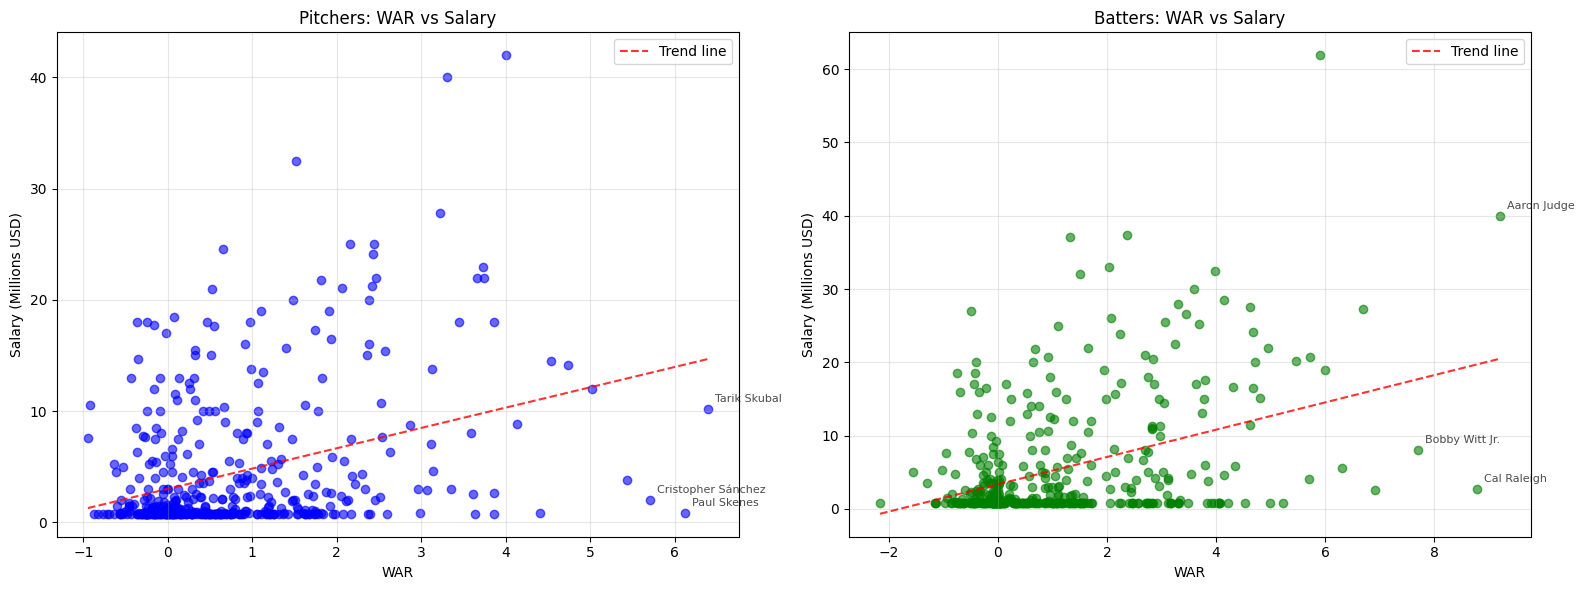

In [7]:
# WAR vs Salary scatter plots
if 'WAR' in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pitcher WAR vs Salary
    pitcher_data = df[df['is_pitcher'] & df['WAR'].notna() & df['salary_2025'].notna()]
    if len(pitcher_data) > 0:
        ax1.scatter(pitcher_data['WAR'], pitcher_data['salary_2025'] / 1_000_000, alpha=0.6, color='blue')
        ax1.set_xlabel('WAR')
        ax1.set_ylabel('Salary (Millions USD)')
        ax1.set_title('Pitchers: WAR vs Salary')
        ax1.grid(True, alpha=0.3)
        
        # Add trend line
        if len(pitcher_data) > 1:
            z = np.polyfit(pitcher_data['WAR'], pitcher_data['salary_2025'] / 1_000_000, 1)
            p = np.poly1d(z)
            war_range = np.linspace(pitcher_data['WAR'].min(), pitcher_data['WAR'].max(), 100)
            ax1.plot(war_range, p(war_range), "r--", alpha=0.8, label='Trend line')
            ax1.legend()
            
        # Annotate a few top players
        if len(pitcher_data) >= 3:
            top_war_pitchers = pitcher_data.nlargest(3, 'WAR')
            for _, player in top_war_pitchers.iterrows():
                ax1.annotate(player['player_name'], 
                           (player['WAR'], player['salary_2025'] / 1_000_000),
                           xytext=(5, 5), textcoords='offset points', 
                           fontsize=8, alpha=0.7)
    else:
        ax1.text(0.5, 0.5, 'No Pitcher Data\\nAvailable', ha='center', va='center', 
                transform=ax1.transAxes, fontsize=14)
    
    # Batter WAR vs Salary
    batter_data = df[~df['is_pitcher'] & df['WAR'].notna() & df['salary_2025'].notna()]
    if len(batter_data) > 0:
        ax2.scatter(batter_data['WAR'], batter_data['salary_2025'] / 1_000_000, alpha=0.6, color='green')
        ax2.set_xlabel('WAR')
        ax2.set_ylabel('Salary (Millions USD)')
        ax2.set_title('Batters: WAR vs Salary')
        ax2.grid(True, alpha=0.3)
        
        # Add trend line
        if len(batter_data) > 1:
            z = np.polyfit(batter_data['WAR'], batter_data['salary_2025'] / 1_000_000, 1)
            p = np.poly1d(z)
            war_range = np.linspace(batter_data['WAR'].min(), batter_data['WAR'].max(), 100)
            ax2.plot(war_range, p(war_range), "r--", alpha=0.8, label='Trend line')
            ax2.legend()
            
        # Annotate a few top players
        if len(batter_data) >= 3:
            top_war_batters = batter_data.nlargest(3, 'WAR')
            for _, player in top_war_batters.iterrows():
                ax2.annotate(player['player_name'], 
                           (player['WAR'], player['salary_2025'] / 1_000_000),
                           xytext=(5, 5), textcoords='offset points', 
                           fontsize=8, alpha=0.7)
    else:
        ax2.text(0.5, 0.5, 'No Batter Data\\nAvailable', ha='center', va='center', 
                transform=ax2.transAxes, fontsize=14)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Skipping WAR vs Salary plots (WAR not available)")


In [8]:
# Comprehensive correlation analysis
print("📈 SALARY CORRELATION ANALYSIS")
print("=" * 35)

# Define key metrics to analyze
batter_metrics = ['WAR', 'OPS', 'wRC+', 'wOBA', 'xwOBA', 'AVG', 'OBP', 'SLG', 'HR', 'RBI', 'SB']
pitcher_metrics = ['WAR', 'ERA', 'FIP', 'WHIP', 'K/9', 'BB/9', 'IP', 'W', 'SV', 'xFIP', 'SIERA']

# Analyze batter correlations
batter_data = df[~df['is_pitcher']].copy()
available_batter_metrics = [col for col in batter_metrics if col in df.columns]

if available_batter_metrics and len(batter_data.dropna(subset=['salary_2025'])) > 1:
    batter_corrs = []
    for metric in available_batter_metrics:
        corr = batter_data[metric].corr(batter_data['salary_2025'])
        if not pd.isna(corr):
            batter_corrs.append((metric, corr))
    
    batter_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
    
    print("\\n🏏 BATTER SALARY CORRELATIONS:")
    for metric, corr in batter_corrs[:8]:
        strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
        direction = "+" if corr > 0 else "-"
        print(f"{metric:<8}: {corr:>6.3f} ({direction} {strength})")

# Analyze pitcher correlations  
pitcher_data = df[df['is_pitcher']].copy()
available_pitcher_metrics = [col for col in pitcher_metrics if col in df.columns]

if available_pitcher_metrics and len(pitcher_data.dropna(subset=['salary_2025'])) > 1:
    pitcher_corrs = []
    for metric in available_pitcher_metrics:
        corr = pitcher_data[metric].corr(pitcher_data['salary_2025'])
        if not pd.isna(corr):
            pitcher_corrs.append((metric, corr))
    
    pitcher_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
    
    print("\\n⚾ PITCHER SALARY CORRELATIONS:")
    for metric, corr in pitcher_corrs[:8]:
        strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
        direction = "+" if corr > 0 else "-"
        print(f"{metric:<8}: {corr:>6.3f} ({direction} {strength})")


📈 SALARY CORRELATION ANALYSIS
\n🏏 BATTER SALARY CORRELATIONS:
HR      :  0.443 (+ Moderate)
xwOBA   :  0.425 (+ Moderate)
RBI     :  0.410 (+ Moderate)
WAR     :  0.400 (+ Moderate)
wRC+    :  0.362 (+ Moderate)
OPS     :  0.362 (+ Moderate)
wOBA    :  0.353 (+ Moderate)
SLG     :  0.339 (+ Moderate)
\n⚾ PITCHER SALARY CORRELATIONS:
IP      :  0.409 (+ Moderate)
W       :  0.377 (+ Moderate)
WAR     :  0.346 (+ Moderate)
BB/9    : -0.176 (- Weak)
WHIP    : -0.166 (- Weak)
xFIP    : -0.131 (- Weak)
ERA     : -0.102 (- Weak)
FIP     : -0.094 (- Weak)


## 🎯 Advanced Market Analysis

Let's dive deeper into market efficiency, expected vs actual performance, and service time effects.


In [9]:
# Expected vs Actual performance analysis
if 'wOBA' in df.columns and 'xwOBA' in df.columns:
    print("🎯 EXPECTED vs ACTUAL PERFORMANCE")
    print("=" * 35)
    
    # Calculate over/under performance
    performance_df = df.dropna(subset=['wOBA', 'xwOBA', 'salary_2025']).copy()
    performance_df['wOBA_diff'] = performance_df['wOBA'] - performance_df['xwOBA']
    
    if len(performance_df) > 0:
        # Players significantly outperforming expected stats
        overperformers = performance_df[performance_df['wOBA_diff'] >= 0.020].nlargest(10, 'wOBA_diff')
        underperformers = performance_df[performance_df['wOBA_diff'] <= -0.020].nsmallest(10, 'wOBA_diff')
        
        if len(overperformers) > 0:
            print("\\n🔥 TOP OVERPERFORMERS (wOBA > xwOBA by 0.020+):")
            for i, (_, row) in enumerate(overperformers.iterrows()):
                salary_millions = row['salary_2025'] / 1_000_000
                print(f"{i+1:2d}. {row['player_name']:<20} wOBA: {row['wOBA']:.3f} xwOBA: {row['xwOBA']:.3f} Diff: +{row['wOBA_diff']:.3f} Salary: ${salary_millions:.1f}M")
        
        if len(underperformers) > 0:
            print("\\n📉 BIGGEST UNDERPERFORMERS (wOBA < xwOBA by 0.020+):")
            for i, (_, row) in enumerate(underperformers.iterrows()):
                salary_millions = row['salary_2025'] / 1_000_000
                print(f"{i+1:2d}. {row['player_name']:<20} wOBA: {row['wOBA']:.3f} xwOBA: {row['xwOBA']:.3f} Diff: {row['wOBA_diff']:.3f} Salary: ${salary_millions:.1f}M")
        
        # Market inefficiency analysis
        avg_overperformer_salary = overperformers['salary_2025'].mean() if len(overperformers) > 0 else 0
        avg_underperformer_salary = underperformers['salary_2025'].mean() if len(underperformers) > 0 else 0
        
        print(f"\\n💡 MARKET INSIGHTS:")
        if len(overperformers) > 0:
            print(f"Average overperformer salary: ${avg_overperformer_salary:,.0f}")
        if len(underperformers) > 0:
            print(f"Average underperformer salary: ${avg_underperformer_salary:,.0f}")
        
        # Overall performance distribution
        mean_diff = performance_df['wOBA_diff'].mean()
        std_diff = performance_df['wOBA_diff'].std()
        print(f"Market average wOBA vs xwOBA difference: {mean_diff:.3f} ± {std_diff:.3f}")
    else:
        print("⚠️ No players with complete wOBA/xwOBA data")
elif 'wOBA' in df.columns:
    print("⚠️ xwOBA not available - cannot perform expected vs actual analysis")
elif 'xwOBA' in df.columns:
    print("⚠️ wOBA not available - cannot perform expected vs actual analysis")
else:
    print("⚠️ Neither wOBA nor xwOBA available - skipping expected vs actual analysis")


🎯 EXPECTED vs ACTUAL PERFORMANCE
\n🔥 TOP OVERPERFORMERS (wOBA > xwOBA by 0.020+):
 1. Jonny DeLuca         wOBA: 0.350 xwOBA: 0.265 Diff: +0.085 Salary: $0.8M
 2. David Fry            wOBA: 0.263 xwOBA: 0.211 Diff: +0.052 Salary: $0.8M
 3. Austin Wynns         wOBA: 0.365 xwOBA: 0.314 Diff: +0.052 Salary: $1.1M
 4. Hyeseong Kim         wOBA: 0.305 xwOBA: 0.260 Diff: +0.045 Salary: $2.8M
 5. Harrison Bader       wOBA: 0.357 xwOBA: 0.312 Diff: +0.045 Salary: $4.8M
 6. Miguel Andujar       wOBA: 0.353 xwOBA: 0.310 Diff: +0.043 Salary: $3.0M
 7. Jacob Wilson         wOBA: 0.350 xwOBA: 0.310 Diff: +0.040 Salary: $0.8M
 8. Matt Mervis          wOBA: 0.274 xwOBA: 0.235 Diff: +0.039 Salary: $0.8M
 9. Brett Harris         wOBA: 0.321 xwOBA: 0.283 Diff: +0.038 Salary: $0.8M
10. Miguel Amaya         wOBA: 0.346 xwOBA: 0.309 Diff: +0.037 Salary: $0.8M
\n📉 BIGGEST UNDERPERFORMERS (wOBA < xwOBA by 0.020+):
 1. Ji Hwan Bae          wOBA: 0.174 xwOBA: 0.288 Diff: -0.114 Salary: $0.8M
 2. Gage Workman 

In [10]:
# Service time vs salary analysis
if 'mls_years' in df.columns:
    print("📊 SERVICE TIME vs SALARY ANALYSIS")
    print("=" * 40)
    
    service_analysis = df.dropna(subset=['mls_years', 'salary_2025']).copy()
    
    if len(service_analysis) > 0:
        # Create service time bins
        service_analysis['service_bin'] = pd.cut(
            service_analysis['mls_years'], 
            bins=[-0.1, 3, 6, 10, 15, 25],
            labels=['0-3 yrs', '3-6 yrs', '6-10 yrs', '10-15 yrs', '15+ yrs']
        )
        
        # Average salary by service time and position
        salary_by_service = service_analysis.groupby(['service_bin', 'is_pitcher'])['salary_2025'].agg(['mean', 'count']).round(0)
        
        print("\\nAverage salary by service time and position:")
        print(salary_by_service)
        
        # Service time correlation
        service_corr = service_analysis['mls_years'].corr(service_analysis['salary_2025'])
        print(f"\\n📈 Service Time-Salary Correlation: {service_corr:.3f}")
        
        # Experience premium analysis
        rookie_contracts = service_analysis[service_analysis['mls_years'] <= 3]['salary_2025'].mean()
        veteran_contracts = service_analysis[service_analysis['mls_years'] > 6]['salary_2025'].mean()
        
        if rookie_contracts > 0 and veteran_contracts > 0:
            experience_premium = (veteran_contracts - rookie_contracts) / rookie_contracts * 100
            print(f"💰 Veteran Premium: {experience_premium:+.1f}% (6+ years vs 0-3 years)")
            print(f"   Rookie avg: ${rookie_contracts:,.0f}")  
            print(f"   Veteran avg: ${veteran_contracts:,.0f}")
    else:
        print("⚠️ No players with both service time and salary data")
else:
    print("⚠️ Service time data (mls_years) not available")


📊 SERVICE TIME vs SALARY ANALYSIS
\nAverage salary by service time and position:
                              mean  count
service_bin is_pitcher                   
0-3 yrs     False        1411274.0    208
            True         1281787.0    218
3-6 yrs     False        6011251.0     96
            True         3895290.0    116
6-10 yrs    False       11985434.0     77
            True         9581574.0     92
10-15 yrs   False       15908323.0     29
            True        14934091.0     22
15+ yrs     False        5000000.0      1
            True        13250000.0      4
\n📈 Service Time-Salary Correlation: 0.626
💰 Veteran Premium: +776.4% (6+ years vs 0-3 years)
   Rookie avg: $1,345,011
   Veteran avg: $11,787,887


## 📊 Market Summary Dashboard

Let's visualize the overall salary market structure and key insights.


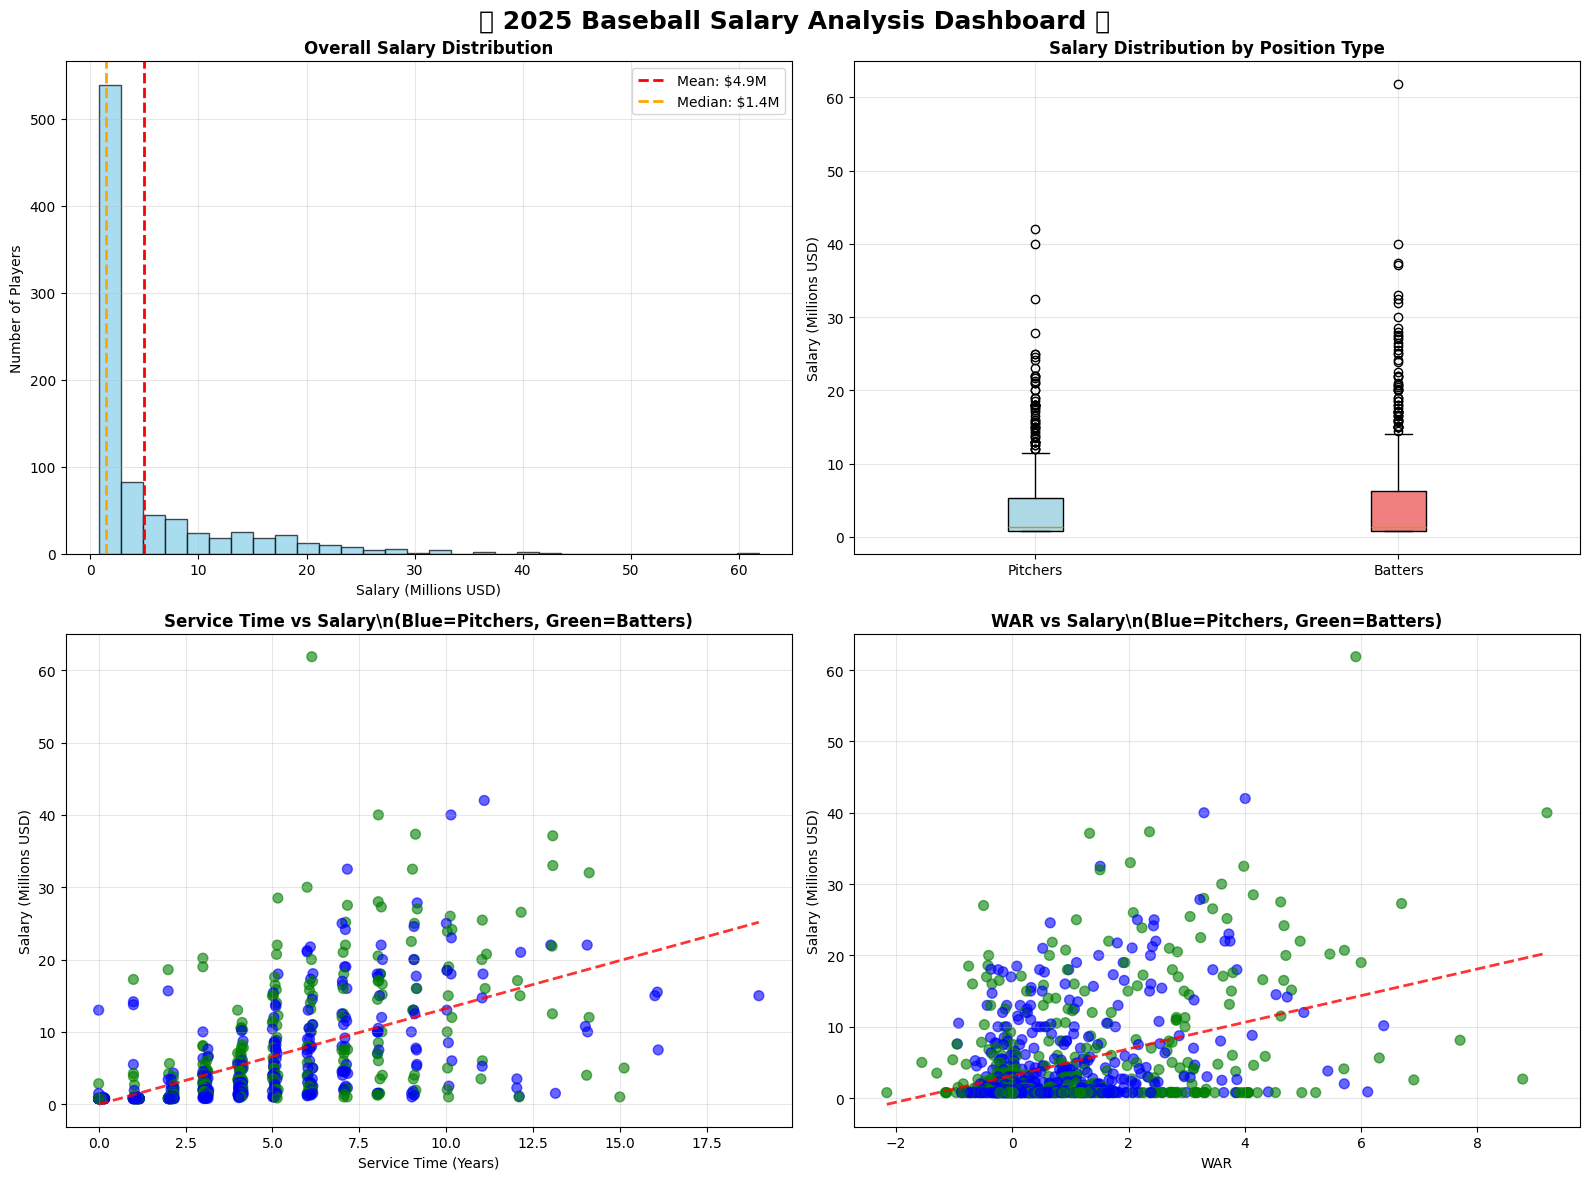

In [11]:
# Create comprehensive salary analysis dashboard
salary_data = df.dropna(subset=['salary_2025'])
pitcher_salaries = salary_data[salary_data['is_pitcher']]['salary_2025']
batter_salaries = salary_data[~salary_data['is_pitcher']]['salary_2025']

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall salary distribution
ax1.hist(salary_data['salary_2025'] / 1_000_000, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(salary_data['salary_2025'].mean() / 1_000_000, color='red', linestyle='--', linewidth=2,
            label=f'Mean: ${salary_data["salary_2025"].mean()/1_000_000:.1f}M')
ax1.axvline(salary_data['salary_2025'].median() / 1_000_000, color='orange', linestyle='--', linewidth=2,
            label=f'Median: ${salary_data["salary_2025"].median()/1_000_000:.1f}M')
ax1.set_xlabel('Salary (Millions USD)')
ax1.set_ylabel('Number of Players')
ax1.set_title('Overall Salary Distribution', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Pitcher vs Batter salary comparison (box plot)
if len(pitcher_salaries) > 0 and len(batter_salaries) > 0:
    bp = ax2.boxplot([pitcher_salaries / 1_000_000, batter_salaries / 1_000_000], 
                     labels=['Pitchers', 'Batters'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    ax2.set_ylabel('Salary (Millions USD)')
    ax2.set_title('Salary Distribution by Position Type', fontweight='bold')
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Insufficient data for\\nposition comparison', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)

# 3. Service time vs salary (if available)
if 'mls_years' in df.columns:
    service_salary = df.dropna(subset=['mls_years', 'salary_2025'])
    if len(service_salary) > 0:
        # Color by position type
        colors = ['blue' if p else 'green' for p in service_salary['is_pitcher']]
        scatter = ax3.scatter(service_salary['mls_years'], service_salary['salary_2025'] / 1_000_000, 
                            alpha=0.6, c=colors, s=50)
        ax3.set_xlabel('Service Time (Years)')
        ax3.set_ylabel('Salary (Millions USD)')
        ax3.set_title('Service Time vs Salary\\n(Blue=Pitchers, Green=Batters)', fontweight='bold')
        ax3.grid(True, alpha=0.3)
        
        # Add trend line
        if len(service_salary) > 1:
            z = np.polyfit(service_salary['mls_years'], service_salary['salary_2025'] / 1_000_000, 1)
            p = np.poly1d(z)
            years_range = np.linspace(service_salary['mls_years'].min(), service_salary['mls_years'].max(), 100)
            ax3.plot(years_range, p(years_range), "r--", alpha=0.8, linewidth=2)
    else:
        ax3.text(0.5, 0.5, 'No Service Time\\nData Available', 
                 ha='center', va='center', transform=ax3.transAxes, fontsize=12)
else:
    ax3.text(0.5, 0.5, 'Service Time\\nData Not Available', 
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)

# 4. WAR vs Salary (if available)
if 'WAR' in df.columns:
    war_salary = df.dropna(subset=['WAR', 'salary_2025'])
    if len(war_salary) > 0:
        colors = ['blue' if p else 'green' for p in war_salary['is_pitcher']]
        scatter = ax4.scatter(war_salary['WAR'], war_salary['salary_2025'] / 1_000_000, 
                            alpha=0.6, c=colors, s=50)
        ax4.set_xlabel('WAR')
        ax4.set_ylabel('Salary (Millions USD)')
        ax4.set_title('WAR vs Salary\\n(Blue=Pitchers, Green=Batters)', fontweight='bold')
        ax4.grid(True, alpha=0.3)
        
        # Add trend line
        if len(war_salary) > 1:
            z = np.polyfit(war_salary['WAR'], war_salary['salary_2025'] / 1_000_000, 1)
            p = np.poly1d(z)
            war_range = np.linspace(war_salary['WAR'].min(), war_salary['WAR'].max(), 100)
            ax4.plot(war_range, p(war_range), "r--", alpha=0.8, linewidth=2)
    else:
        ax4.text(0.5, 0.5, 'No WAR Data\\nAvailable', 
                 ha='center', va='center', transform=ax4.transAxes, fontsize=12)
else:
    ax4.text(0.5, 0.5, 'WAR Data\\nNot Available', 
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)

plt.suptitle('⚾ 2025 Baseball Salary Analysis Dashboard ⚾', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [12]:
# Final market summary and insights
print("📊 2025 BASEBALL SALARY MARKET SUMMARY")
print("=" * 40)

salary_data = df.dropna(subset=['salary_2025'])

print(f"\n💰 OVERALL MARKET:")
print(f"Total players analyzed: {len(salary_data):,}")
print(f"Total payroll: ${salary_data['salary_2025'].sum():,.0f}")
print(f"Average salary: ${salary_data['salary_2025'].mean():,.0f}")
print(f"Median salary: ${salary_data['salary_2025'].median():,.0f}")
print(f"Salary range: ${salary_data['salary_2025'].min():,.0f} - ${salary_data['salary_2025'].max():,.0f}")

# Position breakdown
pitcher_salaries = salary_data[salary_data['is_pitcher']]['salary_2025']
batter_salaries = salary_data[~salary_data['is_pitcher']]['salary_2025']

if len(pitcher_salaries) > 0:
    print(f"\n⚾ PITCHERS ({len(pitcher_salaries):,} players):")
    print(f"Average: ${pitcher_salaries.mean():,.0f}")
    print(f"Median: ${pitcher_salaries.median():,.0f}")
    print(f"Top salary: ${pitcher_salaries.max():,.0f}")

if len(batter_salaries) > 0:
    print(f"\n🏏 BATTERS ({len(batter_salaries):,} players):")
    print(f"Average: ${batter_salaries.mean():,.0f}")
    print(f"Median: ${batter_salaries.median():,.0f}")
    print(f"Top salary: ${batter_salaries.max():,.0f}")

# Market concentration analysis
if len(salary_data) >= 10:
    top_10_pct = salary_data.nlargest(max(1, int(len(salary_data) * 0.1)), 'salary_2025')
    concentration = top_10_pct['salary_2025'].sum() / salary_data['salary_2025'].sum() * 100
    
    print(f"\n📈 MARKET CONCENTRATION:")
    print(f"Top 10% of players earn {concentration:.1f}% of total payroll")
    print(f"Top 10% salary threshold: ${top_10_pct['salary_2025'].min():,.0f}")

# Performance insights (if WAR available)
if 'WAR' in df.columns:
    war_data = df.dropna(subset=['WAR', 'salary_2025'])
    if len(war_data) > 0:
        total_war = war_data['WAR'].sum()
        avg_cost_per_war = war_data['salary_2025'].sum() / total_war if total_war > 0 else 0
        
        print(f"\n🏆 PERFORMANCE MARKET:")
        print(f"Total WAR produced: {total_war:.1f}")
        print(f"Average cost per WAR: ${avg_cost_per_war:,.0f}")
        
        # Most efficient teams (if team data available)
        team_cols = [col for col in ['TeamName', 'TeamNameAbb'] if col in df.columns]
        if team_cols:
            team_col = team_cols[0]
            team_efficiency = war_data.groupby(team_col).agg({
                'salary_2025': 'sum',
                'WAR': 'sum',
                'player_name': 'count'
            }).copy()
            team_efficiency.columns = ['total_salary', 'total_war', 'player_count']
            team_efficiency = team_efficiency[team_efficiency['total_war'] > 0]
            team_efficiency['cost_per_war'] = team_efficiency['total_salary'] / team_efficiency['total_war']
            
            if len(team_efficiency) >= 5:
                most_efficient = team_efficiency.nsmallest(5, 'cost_per_war')
                print(f"\n💡 MOST EFFICIENT TEAMS (lowest $/WAR):")
                for team, row in most_efficient.iterrows():
                    print(f"{str(team):<8}: ${row['cost_per_war']:>8,.0f}/WAR ({row['player_count']:2.0f} players, {row['total_war']:.1f} WAR)")

# Handedness analysis (if available)
if 'handedness' in df.columns:
    handedness_analysis = df.dropna(subset=['handedness', 'salary_2025'])
    if len(handedness_analysis) > 0:
        handedness_stats = handedness_analysis.groupby(['handedness', 'is_pitcher'])['salary_2025'].mean()
        print(f"\n🤚 HANDEDNESS PREMIUMS:")
        for (hand, is_pitcher), avg_salary in handedness_stats.items():
            pos_type = "Pitcher" if is_pitcher else "Batter"
            print(f"{hand}-handed {pos_type}s: ${avg_salary:,.0f} average")

print(f"\n" + "="*40)
print(f"🎯 ANALYSIS COMPLETE!")
print(f"Dataset: {len(df)} total players")
print(f"With salary data: {len(salary_data)} players")
print(f"📊 Use this data to identify market inefficiencies,")
print(f"   undervalued players, and salary vs performance trends!")
print("="*40)


📊 2025 BASEBALL SALARY MARKET SUMMARY

💰 OVERALL MARKET:
Total players analyzed: 863
Total payroll: $4,254,182,893
Average salary: $4,929,528
Median salary: $1,400,000
Salary range: $760,000 - $61,875,000

⚾ PITCHERS (452 players):
Average: $4,412,252
Median: $1,375,000
Top salary: $42,000,000

🏏 BATTERS (411 players):
Average: $5,498,406
Median: $1,400,000
Top salary: $61,875,000

📈 MARKET CONCENTRATION:
Top 10% of players earn 45.9% of total payroll
Top 10% salary threshold: $15,750,000

🏆 PERFORMANCE MARKET:
Total WAR produced: 819.1
Average cost per WAR: $5,193,625

💡 MOST EFFICIENT TEAMS (lowest $/WAR):
MIL     : $1,890,990/WAR (25 players, 33.9 WAR)
TBR     : $1,891,049/WAR (23 players, 22.8 WAR)
MIA     : $2,056,825/WAR (26 players, 18.7 WAR)
CLE     : $2,725,507/WAR (25 players, 23.6 WAR)
STL     : $3,230,264/WAR (21 players, 18.2 WAR)

🤚 HANDEDNESS PREMIUMS:
B-handed Batters: $5,025,535 average
L-handed Batters: $4,971,755 average
L-handed Pitchers: $3,972,693 average
R-handed